# CovCollExamples\n\nCollections of Covariate objects.\n\nPython port of the MATLAB `CovCollExamples` helpfile (`helpfiles/CovCollExamples.m`).

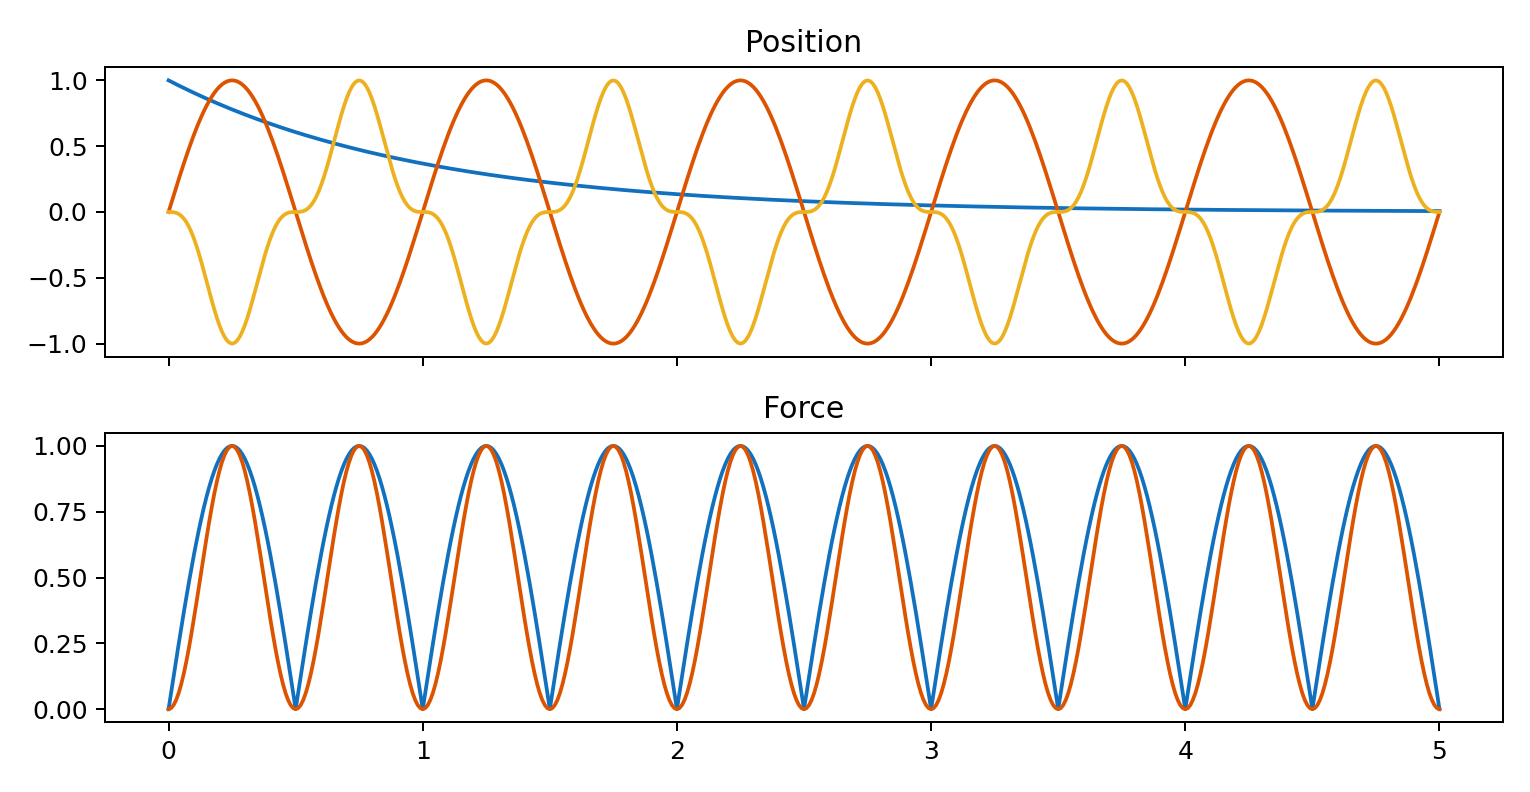

In [ ]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import SignalObj, Covariate, CovColl, Events, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="CovCollExamples", output_root=OUTPUT_ROOT, expected_count=2)

def capture(label, fn):
    """For plot methods that build their own figure: discard the tracker
    placeholder, run the plot, then capture the figure it created."""
    fig = __tracker.new_figure(label)
    plt.close(fig)
    fn()
    __tracker._active_fig = plt.gcf()


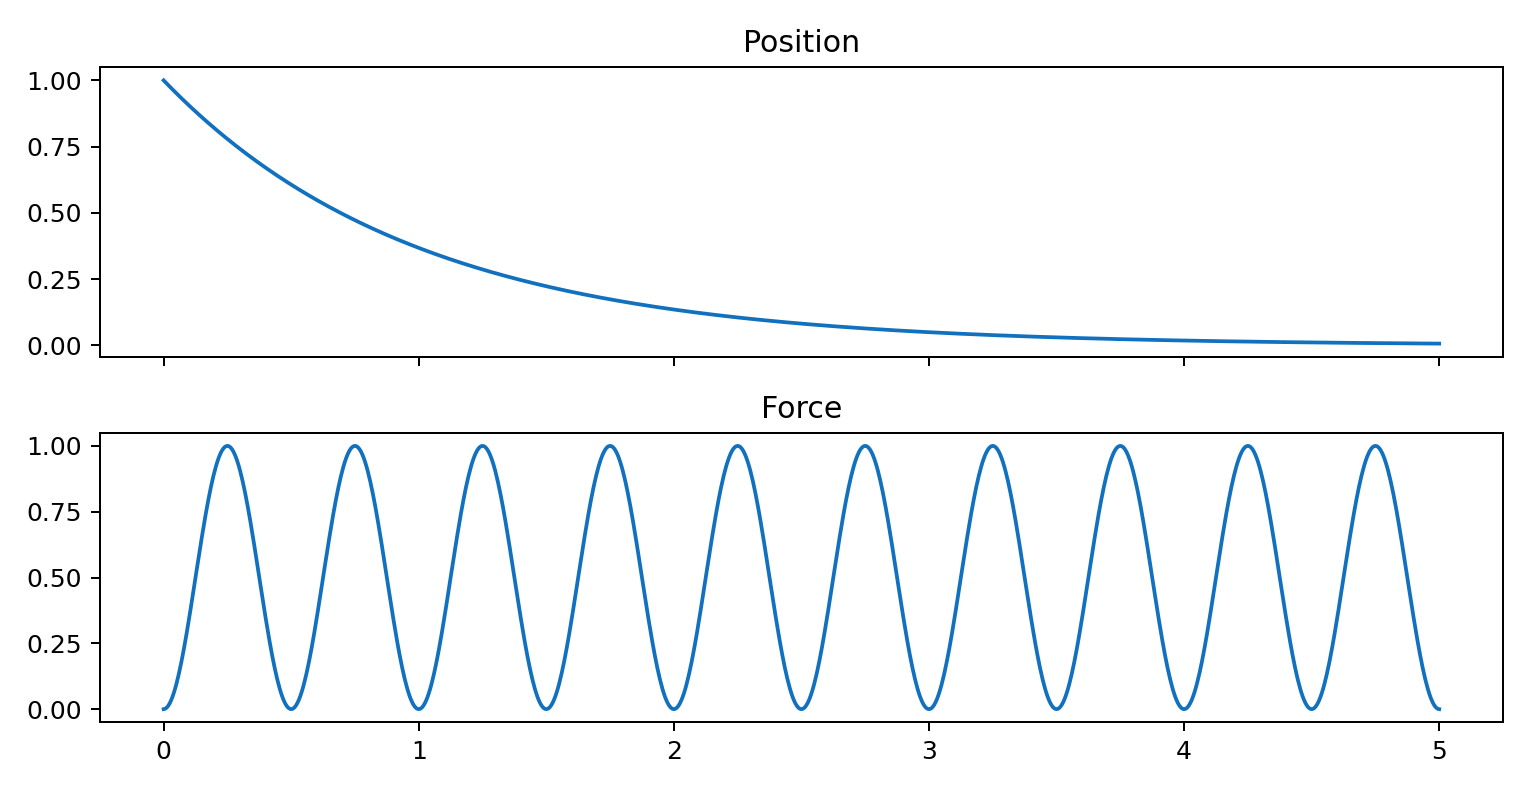

In [ ]:
t = np.arange(0, 5 + 0.01, 0.01)
x = np.exp(-t); y = np.sin(2*np.pi*t); z = (-y)**3
fx = np.abs(y); fy = np.abs(y)**2
force = Covariate(t, np.vstack([fx, fy]).T, "Force", "time", "s", "N", ["f_x","f_y"])
position = Covariate(t, np.vstack([x, y, z]).T, "Position", "time", "s", "cm", ["x","y","z"])
cc = CovColl([position, force])
capture("cc.plot() — all covariates", lambda: cc.plot())
cc.resample(200)
cc.setMask([["Position","x"], ["Force","f_y"]])
capture("cc.plot() — masked to Position.x and Force.f_y", lambda: cc.plot())
__tracker.finalize()
